# 11 - MobileNetV2 + 4-Block Transformer Temporal Experiment (Stage 2 Removed)
## Tai Phake Visual Speech Recognition (VSR) Project

### Experiment: Stage 2 Removed

**Purpose:**
Determine whether fine-tuning the last 20% of MobileNetV2 hurts speaker-independent generalization.

**Dataset:**
96×96 augmented training data with original-only validation.

### Controlled Experiment Context & Hypothesis
In the baseline 96×96 MobileNetV2 + 4-Block Transformer experiment (which achieved ~42.42% validation accuracy), the training was conducted using a two-stage regime:
1. **Stage 1:** MobileNetV2 frozen, Adam (learning rate = $1\times 10^{-4}$), max 40 epochs, patience 8.
2. **Stage 2:** Top 20% of MobileNetV2 unfrozen (with `BatchNormalization` frozen), Adam (learning rate = $1\times 10^{-5}$), max 25 epochs, patience 6.

While fine-tuning the visual frontend is conventional in computer vision transfer learning, in low-resource isolated digit lip reading with small speaker cohorts, fine-tuning even the top 20% of the CNN visual backbone may lead to:
- **Speaker feature over-adaptation / overfitting:** The backbone learns speaker-specific visual idiosyncrasies of the 24 training speakers rather than invariant lip dynamics.
- **Degradation of speaker-independent generalization:** Validation performance on unseen speakers drops or fails to improve past early Stage 1 checkpoints.

To test this hypothesis directly, **this controlled experiment completely REMOVES Stage 2 fine-tuning**. The MobileNetV2 visual frontend remains 100% frozen throughout the entire training lifecycle. All other architectural, optimization, and preprocessing parameters are kept strictly identical to isolate this single independent variable:
$$\text{Stage 2 Fine-Tuning: ON vs. OFF}$$

### Experimental Protocol & Fairness Controls
- **Dataset**: 96 × 96 RGB mouth crops, 30 frames per utterance.
- **Dataset Mode**: `DATASET_MODE = "80_20"`
  - **Training Partition**: 24 base speakers × 5 folders (original + aug1–aug4) = 120 training directories. All folders belonging to a base speaker remain strictly in the training partition.
  - **Validation Partition**: 6 unseen base speakers × **ORIGINAL folder only** = 6 validation directories. (No augmented validation folders are loaded).
  - **Test Partition**: Disabled.
- **Visual Frontend**: ImageNet-pretrained `MobileNetV2` (`include_top=False`, `pooling='avg'`, 1280 features per frame). **Completely frozen (`trainable = False`) throughout**.
- **Temporal Architecture**:
  - TimeDistributed linear projection: $1280 \rightarrow 256$
  - LayerNormalization
  - Deterministic Sinusoidal Positional Encoding ($T=30$, $D=256$)
  - **4 stacked Transformer Encoder blocks** (Pre-LN, 4 attention heads, $\text{key\_dim}=64$, $\text{FFN}=512$, GELU activation, $\text{dropout}=0.2$, residual connections)
  - GlobalAveragePooling1D across the 30 temporal frames
  - Head Dropout (0.4)
  - Dense(11, activation="softmax")
- **Single-Stage Training Protocol (Stage 1 Only)**:
  - Adam optimizer (learning rate = $1\times 10^{-4}$)
  - Sparse-label-compatible Label Smoothing ($0.1$)
  - Batch size = 16, shuffle = True
  - Max epochs = 40, EarlyStopping (patience = 8, monitoring `val_loss`, restore best weights = True)
  - ModelCheckpoint saving best weights to `mobilenetv2_transformer_4block_stage2_removed_best.weights.h5`
- **Stage 2**: **COMPLETELY REMOVED / DISABLED**.

In [1]:
# =============================================================================
# EXPERIMENT CONFIGURATION
# =============================================================================

DATASET_MODE = "80_20"
# Controlled Experiment: 80_20 split with 24 train base speakers (120 dirs) and 6 val base speakers (6 original dirs)

## 2. Imports
Importing core scientific libraries, deep learning frameworks (TensorFlow, Keras), image processing tools, and scikit-learn evaluation metrics.

In [2]:
# Section 2: Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import sklearn.metrics as metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
import keras

print("=" * 80)
print("ENVIRONMENT & DEPENDENCY VERSIONS")
print("=" * 80)
print(f"Python Version:     {sys.version.split()[0]}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"Available GPUs:     {len(gpu_devices)} ({gpu_devices})")
print("=" * 80)

ENVIRONMENT & DEPENDENCY VERSIONS
Python Version:     3.12.13
TensorFlow Version: 2.21.0
Keras Version:      3.15.1
Available GPUs:     0 ([])


## 3. Configuration
Defining deterministic random seeds, image and sequence parameters, Transformer architecture hyperparameters (4 encoder blocks), and single-stage training settings (Stage 2 removed).

In [3]:
# Section 3: Configuration & Hyperparameters
SEED = 42

# Reproducibility seeding
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Sequence & Image Specifications (Method D standard)
NUM_CLASSES = 11
NUM_FRAMES = 30
FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3
BATCH_SIZE = 16

# Transformer Architecture Hyperparameters (4-Block Configuration)
EMBED_DIM = 256
NUM_HEADS = 4
KEY_DIM = 64          # 4 heads * 64 key_dim = 256
FFN_DIM = 512
NUM_TRANSFORMER_BLOCKS = 4  # 4 stacked Transformer encoder blocks
TRANSFORMER_DROPOUT = 0.2
HEAD_DROPOUT = 0.4

# Single-Stage Training Hyperparameters (Stage 2 Removed)
STAGE1_LR = 1e-4
STAGE1_MAX_EPOCHS = 40
STAGE1_PATIENCE = 8
LABEL_SMOOTHING = 0.1      # BiLSTM baseline matching label smoothing

# Target Digit Classes (d0 through d10)
DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print("=" * 80)
print("EXPERIMENT CONFIGURATION & HYPERPARAMETERS [Stage 2 Removed]")
print("=" * 80)
print(f"Experiment                   : Stage 2 Removed (MobileNetV2 100% Frozen)")
print(f"Dataset Mode                 : {DATASET_MODE}")
print(f"Random Seed                  : {SEED}")
print(f"Target Digit Classes ({len(DIGIT_CLASSES)})   : {DIGIT_CLASSES}")
print(f"Input Sequence Shape         : ({NUM_FRAMES} frames, {FRAME_HEIGHT}x{FRAME_WIDTH}, {FRAME_CHANNELS} channels)")
print(f"Batch Size                   : {BATCH_SIZE}")
print(f"Transformer Depth            : {NUM_TRANSFORMER_BLOCKS} Blocks")
print(f"Transformer Attention Heads  : {NUM_HEADS} (key_dim={KEY_DIM}, embed_dim={EMBED_DIM})")
print(f"Transformer FFN Dimension    : {FFN_DIM}")
print(f"Transformer Dropout          : {TRANSFORMER_DROPOUT}")
print(f"Head Dropout                 : {HEAD_DROPOUT}")
print(f"Label Smoothing              : {LABEL_SMOOTHING}")
print(f"Training Setup (Stage 1 Only): Adam(lr={STAGE1_LR}), max_epochs={STAGE1_MAX_EPOCHS}, patience={STAGE1_PATIENCE}")
print(f"Stage 2 Fine-Tuning          : DISABLED")
print("=" * 80)

EXPERIMENT CONFIGURATION & HYPERPARAMETERS [Stage 2 Removed]
Experiment                   : Stage 2 Removed (MobileNetV2 100% Frozen)
Dataset Mode                 : 80_20
Random Seed                  : 42
Target Digit Classes (11)   : ['d0', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10']
Input Sequence Shape         : (30 frames, 96x96, 3 channels)
Batch Size                   : 16
Transformer Depth            : 4 Blocks
Transformer Attention Heads  : 4 (key_dim=64, embed_dim=256)
Transformer FFN Dimension    : 512
Transformer Dropout          : 0.2
Head Dropout                 : 0.4
Label Smoothing              : 0.1
Training Setup (Stage 1 Only): Adam(lr=0.0001), max_epochs=40, patience=8
Stage 2 Fine-Tuning          : DISABLED


## 4. Dataset Paths
Configuring paths for the active 96×96 processed dataset (`data/processed`) and creating a dedicated output directory for this Stage-2-removed experiment (`results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20`).

In [4]:
# Section 4: Dataset Paths Configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

# Dedicated Results Directory (Stage 2 Removed)
RESULTS_DIR = PROJECT_ROOT / "results" / f"mobilenetv2_transformer_4block_stage2_removed_96x96_{DATASET_MODE}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

test_path_str = str(TEST_DIR) if DATASET_MODE == "100_3_3" else "DISABLED"

print("=" * 80)
print("DIRECTORY & EXPERIMENT CONFIGURATION [Stage 2 Removed]")
print("=" * 80)
print(f"Dataset Mode: {DATASET_MODE}")
print(f"Train:        {TRAIN_DIR}")
print(f"Validation:   {VAL_DIR}")
print(f"Test:         {test_path_str}")
print(f"Results:      {RESULTS_DIR}")
print("=" * 80)

DIRECTORY & EXPERIMENT CONFIGURATION [Stage 2 Removed]
Dataset Mode: 80_20
Train:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/train
Validation:   /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/val
Test:         DISABLED
Results:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20


## 5. Speaker Split Verification & Diagnostics
Validating speaker partitions to guarantee strictly zero data leakage:
- **Training partition**: 24 base speakers represented across 120 directories (5 folders per speaker: original, aug1, aug2, aug3, aug4). All folders belonging to a base speaker remain in the training split.
- **Validation partition**: 6 unseen base speakers filtered to **ORIGINAL / UN-AUGMENTED directories only** (6 directories total). No augmented folders (`s25_aug1`, etc.) are permitted.
- **Test partition**: Cleanly disabled.
- **Leakage check**: Asserting that train and validation base speakers have strictly empty intersection.

In [5]:
# Section 5: Speaker Split Verification & Diagnostics
def get_base_speaker(spk_name: str) -> str:
    return spk_name.split("_")[0]

def is_original_folder(spk_name: str) -> bool:
    # Original folder has no augmentation/duplication suffix (e.g. 's25' vs 's25_aug1')
    return "_" not in spk_name

# Index train speakers
train_speakers = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])

# Index validation speakers: FILTER TO ONLY ORIGINAL/UN-AUGMENTED DIRECTORIES
raw_val_dirs = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])
val_speakers = sorted([d for d in raw_val_dirs if is_original_folder(d)])

test_speakers = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]) if TEST_DIR.exists() else []

base_train_speakers = sorted(
    list({get_base_speaker(s) for s in train_speakers}),
    key=lambda x: int(re.search(r"\d+", x).group(0)) if re.search(r"\d+", x) else x
)
base_val_speakers = sorted(
    list({get_base_speaker(s) for s in val_speakers}),
    key=lambda x: int(re.search(r"\d+", x).group(0)) if re.search(r"\d+", x) else x
)
base_test_speakers = sorted(
    list({get_base_speaker(s) for s in test_speakers}),
    key=lambda x: int(re.search(r"\d+", x).group(0)) if re.search(r"\d+", x) else x
)

set_train_base = set(base_train_speakers)
set_val_base = set(base_val_speakers)
set_test_base = set(base_test_speakers)

if DATASET_MODE == "80_20":
    # 1. Zero overlap between Train and Val base speakers
    assert len(set_train_base.intersection(set_val_base)) == 0, (
        f"DATA LEAKAGE: Overlap between Train and Val base speakers: {set_train_base.intersection(set_val_base)}"
    )

    # 2. Exactly 24 base train speakers and 120 directories
    assert len(base_train_speakers) == 24, (
        f"Expected 24 base train speakers in 80/20 mode, found {len(base_train_speakers)}"
    )
    assert len(train_speakers) == 120, (
        f"Expected 120 train directories in 80/20 mode, found {len(train_speakers)}"
    )

    # 3. Exactly 6 base val speakers and 6 original directories
    assert len(base_val_speakers) == 6, (
        f"Expected 6 base val speakers in 80/20 mode, found {len(base_val_speakers)}"
    )
    assert len(val_speakers) == 6, (
        f"Expected 6 original val directories in 80/20 mode, found {len(val_speakers)}"
    )

    # 4. Confirm no augmented validation folders are being loaded
    assert all(is_original_folder(s) for s in val_speakers), (
        f"DATA LEAKAGE: Augmented folder found in validation: {[s for s in val_speakers if not is_original_folder(s)]}"
    )

    # 5. Confirm all folder base speakers map correctly
    for s in train_speakers:
        assert get_base_speaker(s) in set_train_base, f"DATA LEAKAGE: Folder {s} not in train base speakers!"
    for s in val_speakers:
        assert get_base_speaker(s) in set_val_base, f"DATA LEAKAGE: Folder {s} not in val base speakers!"

    # 6. Test split cleanly disabled / empty
    assert len(test_speakers) == 0, f"DATA LEAKAGE: Test folder should be empty in 80/20 mode, found {test_speakers}"

print("=" * 80)
print(f"SPEAKER PARTITION DIAGNOSTICS [Mode: {DATASET_MODE} | Stage 2 Removed]")
print("=" * 80)
print("Training:")
print(f"{len(base_train_speakers)} base speakers / {len(train_speakers)} directories")
print("")
print("Validation:")
print(f"{len(base_val_speakers)} base speakers / {len(val_speakers)} original directories")
print("")
print("Test:")
print("disabled")
print("-" * 80)
print(f"Actual Validation Directories ({len(val_speakers)}): {val_speakers}")
print(f"Validation Base Speakers     ({len(base_val_speakers)}): {base_val_speakers}")
print("-" * 80)
print("[SUCCESS] ALL STRICT ZERO-LEAKAGE ASSERTIONS PASSED:")
print("  [x] Train base speakers = 24")
print(f"  [x] Train directories = {len(train_speakers)} (24 speakers x 5 folders)")
print("  [x] Validation base speakers = 6")
print(f"  [x] Validation directories = {len(val_speakers)} (Original folders only)")
print("  [x] Train & Val base speakers: Zero overlap (Empty intersection)")
print("  [x] No augmented validation folders loaded")
print("  [x] Test split: Cleanly disabled / empty")
print("=" * 80)

# Save speaker split metadata
split_metadata = {
    "experiment": "mobilenetv2_transformer_4block_stage2_removed",
    "dataset_mode": DATASET_MODE,
    "random_seed": SEED,
    "num_train_folders": len(train_speakers),
    "num_base_train_speakers": len(base_train_speakers),
    "num_val_folders": len(val_speakers),
    "num_base_val_speakers": len(base_val_speakers),
    "num_test_folders": len(test_speakers),
    "num_base_test_speakers": len(base_test_speakers),
    "base_train_speakers": base_train_speakers,
    "train_speakers": train_speakers,
    "base_val_speakers": base_val_speakers,
    "val_speakers": val_speakers,
    "base_test_speakers": base_test_speakers,
    "test_speakers": test_speakers,
}
with open(RESULTS_DIR / "speaker_split.json", "w") as f:
    json.dump(split_metadata, f, indent=2)
print(f"Speaker partition metadata saved to: {RESULTS_DIR / 'speaker_split.json'}")

SPEAKER PARTITION DIAGNOSTICS [Mode: 80_20 | Stage 2 Removed]
Training:
24 base speakers / 120 directories

Validation:
6 base speakers / 6 original directories

Test:
disabled
--------------------------------------------------------------------------------
Actual Validation Directories (6): ['s25', 's26', 's27', 's28', 's29', 's30']
Validation Base Speakers     (6): ['s25', 's26', 's27', 's28', 's29', 's30']
--------------------------------------------------------------------------------
[SUCCESS] ALL STRICT ZERO-LEAKAGE ASSERTIONS PASSED:
  [x] Train base speakers = 24
  [x] Train directories = 120 (24 speakers x 5 folders)
  [x] Validation base speakers = 6
  [x] Validation directories = 6 (Original folders only)
  [x] Train & Val base speakers: Zero overlap (Empty intersection)
  [x] No augmented validation folders loaded
  [x] Test split: Cleanly disabled / empty
Speaker partition metadata saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2

## 6. Manifest Creation
Indexing video utterance sequences into a unified manifest dataframe.
- **Train split**: 120 directories (24 base speakers × 5 folders).
- **Val split**: 6 original directories (6 unseen base speakers, original only).
- **Test split**: Disabled.

In [6]:
# Section 6: Manifest Creation
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

utterances = []

# Index Train Split (all 120 directories from train_speakers)
for spk in train_speakers:
    s_path = TRAIN_DIR / spk
    base_spk = get_base_speaker(spk)
    for digit in DIGIT_CLASSES:
        digit_dir = s_path / digit
        if not digit_dir.exists():
            continue
        frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
        if len(frames) == 0:
            continue
        utterances.append({
            "speaker": spk,
            "base_speaker": base_spk,
            "digit": digit,
            "digit_id": CLASS_TO_ID[digit],
            "split": "train",
            "raw_frame_count": len(frames),
            "frame_paths": frames
        })

# Index Validation Split: FILTER ONLY ORIGINAL VALIDATION DIRECTORIES (val_speakers: 6 directories)
for spk in val_speakers:
    s_path = VAL_DIR / spk
    base_spk = get_base_speaker(spk)
    for digit in DIGIT_CLASSES:
        digit_dir = s_path / digit
        if not digit_dir.exists():
            continue
        frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
        if len(frames) == 0:
            continue
        utterances.append({
            "speaker": spk,
            "base_speaker": base_spk,
            "digit": digit,
            "digit_id": CLASS_TO_ID[digit],
            "split": "val",
            "raw_frame_count": len(frames),
            "frame_paths": frames
        })

df_manifest = pd.DataFrame(utterances)

print("=" * 80)
print(f"UTTERANCE MANIFEST SUMMARY [Mode: {DATASET_MODE} | Stage 2 Removed]")
print("=" * 80)
print(f"Total Utterances Indexed: {len(df_manifest):,}")
print(f"  Train Split : {len(df_manifest[df_manifest['split']=='train']):,} utterances ({len(train_speakers)} folders, {len(base_train_speakers)} base speakers)")
print(f"  Val Split   : {len(df_manifest[df_manifest['split']=='val']):,} utterances ({len(val_speakers)} original folders, {len(base_val_speakers)} base speakers)")
print(f"  Test Split  : DISABLED (no test split)")
print("=" * 80)

# Save manifest to CSV
manifest_csv_path = RESULTS_DIR / "utterance_manifest.csv"
df_manifest[["speaker", "base_speaker", "digit", "digit_id", "split", "raw_frame_count"]].to_csv(
    manifest_csv_path, index=False
)
print(f"Manifest saved to: {manifest_csv_path}")

UTTERANCE MANIFEST SUMMARY [Mode: 80_20 | Stage 2 Removed]
Total Utterances Indexed: 1,386
  Train Split : 1,320 utterances (120 folders, 24 base speakers)
  Val Split   : 66 utterances (6 original folders, 6 base speakers)
  Test Split  : DISABLED (no test split)
Manifest saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/utterance_manifest.csv


## 7. Frame Sampling & In-Memory Loading
Temporal standardization and in-memory tensor construction:
1. Each video utterance is deterministically sampled to exactly **30 frames** using uniform linear interpolation across the raw frame timeline (`np.linspace`).
2. The sampled 30 frames are loaded as 96 × 96 RGB images in `[0.0, 255.0]` float32 format.
3. Sequences are partitioned into contiguous train and validation tensors.

In [7]:
# Section 7: Frame Sampling & In-Memory Sequence Loading
def sample_30_frames(frame_paths: list, target_frames: int = NUM_FRAMES) -> list:
    """
    Deterministic temporal sampling across the video duration.
    Produces exactly target_frames (30) uniformly distributed frame indices.
    """
    n = len(frame_paths)
    if n == target_frames:
        indices = list(range(target_frames))
    else:
        indices = np.round(np.linspace(0, n - 1, target_frames)).astype(int)
    return [str(frame_paths[i]) for i in indices]

df_manifest["sampled_frame_paths"] = df_manifest["frame_paths"].apply(sample_30_frames)
print(f"Standardized all {len(df_manifest):,} utterances to exactly {NUM_FRAMES} frames.")

def load_all_video_sequences():
    """
    Loads all sampled frames into contiguous NumPy tensors.
    """
    X_data = np.zeros(
        (len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        dtype=np.float32
    )
    y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)

    t0 = time.time()
    for i, row in df_manifest.iterrows():
        for t, fpath in enumerate(row["sampled_frame_paths"]):
            img = Image.open(fpath).convert("RGB")
            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
            X_data[i, t] = np.array(img, dtype=np.float32)

    elapsed = time.time() - t0
    return X_data, y_data, elapsed

print("Loading video sequence tensors into memory...")
X_all, y_all, load_elapsed = load_all_video_sequences()

# Split into train and val arrays
train_mask = (df_manifest["split"] == "train").values
val_mask = (df_manifest["split"] == "val").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = None, None

print(f"Successfully loaded {len(X_all):,} video sequences in {load_elapsed:.2f}s!")

Standardized all 1,386 utterances to exactly 30 frames.
Loading video sequence tensors into memory...
Successfully loaded 1,386 video sequences in 8.90s!


## 8. Dataset Statistics & Sanity Checks
Validating data shapes, memory footprints, intensity ranges, and ensuring zero NaNs/Infs and full class balance.

In [8]:
# Section 8: Dataset Statistics & Sanity Verification
print("=" * 80)
print(f"DATASET TENSOR STATISTICS & INTEGRITY [Mode: {DATASET_MODE} | Stage 2 Removed]")
print("=" * 80)
print(f"X_all Shape                 : {X_all.shape}")
print(f"Memory Footprint            : {X_all.nbytes / (1024**2):.1f} MB")
print(f"Pixel Intensity Range       : [{X_all.min():.1f}, {X_all.max():.1f}]")
print(f"X_train Shape               : {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val Shape                 : {X_val.shape}   | y_val:   {y_val.shape}")
print("X_test Shape                : DISABLED (no test split in 80/20 mode)")
print("-" * 80)

# Shape assertions
assert X_train.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_train shape: {X_train.shape}"
assert X_val.shape[1:] == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), f"Unexpected X_val shape: {X_val.shape}"

# Numerical validity
assert not np.isnan(X_train).any(), "NaN values detected in X_train!"
assert not np.isnan(X_val).any(), "NaN values detected in X_val!"
assert not np.isinf(X_train).any(), "Inf values detected in X_train!"
assert not np.isinf(X_val).any(), "Inf values detected in X_val!"

# Class representation
assert set(np.unique(y_train)) == set(range(NUM_CLASSES)), "Missing classes in train split!"
assert set(np.unique(y_val)) == set(range(NUM_CLASSES)), "Missing classes in validation split!"

print("Sanity Checks Passed:")
print(f"  [x] Expected sequence dimensions ({NUM_FRAMES}, {FRAME_HEIGHT}, {FRAME_WIDTH}, {FRAME_CHANNELS}) confirmed")
print("  [x] Zero NaN and zero Inf values confirmed across active splits")
print(f"  [x] All {NUM_CLASSES} digit classes (d0..d10) fully represented across active splits")
print("=" * 80)

DATASET TENSOR STATISTICS & INTEGRITY [Mode: 80_20 | Stage 2 Removed]
X_all Shape                 : (1386, 30, 96, 96, 3)
Memory Footprint            : 4385.4 MB
Pixel Intensity Range       : [0.0, 255.0]
X_train Shape               : (1320, 30, 96, 96, 3) | y_train: (1320,)
X_val Shape                 : (66, 30, 96, 96, 3)   | y_val:   (66,)
X_test Shape                : DISABLED (no test split in 80/20 mode)
--------------------------------------------------------------------------------
Sanity Checks Passed:
  [x] Expected sequence dimensions (30, 96, 96, 3) confirmed
  [x] Zero NaN and zero Inf values confirmed across active splits
  [x] All 11 digit classes (d0..d10) fully represented across active splits


## 9. Sinusoidal Positional Encoding
Standard deterministic sinusoidal positional encoding (Vaswani et al., 2017) applied to the 30-frame temporal dimension ($T=30$, $D=256$):
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

In [9]:
# Section 9: Sinusoidal Positional Encoding Layer
class PositionalEncoding(keras.layers.Layer):
    """
    Sinusoidal positional encoding layer for sequence length T=30 and embed_dim=256.
    Adds a fixed, non-trainable (1, T, D) positional encoding tensor to the input.
    """
    def __init__(self, seq_len: int = NUM_FRAMES, dim: int = EMBED_DIM, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.dim = dim

        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(dim)[np.newaxis, :]
        angles = pos / np.power(10000.0, (2 * (i // 2)) / np.float32(dim))

        pe = np.zeros((1, seq_len, dim), dtype=np.float32)
        pe[0, :, 0::2] = np.sin(angles[:, 0::2])
        pe[0, :, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pe

    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.seq_len, "dim": self.dim})
        return config

# Verification
pe_test = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM)
dummy_tensor = tf.zeros((1, NUM_FRAMES, EMBED_DIM))
encoded_tensor = pe_test(dummy_tensor)
assert encoded_tensor.shape == (1, NUM_FRAMES, EMBED_DIM), f"Unexpected shape: {encoded_tensor.shape}"
print(f"PositionalEncoding verified: output shape {encoded_tensor.shape} matches expected (1, {NUM_FRAMES}, {EMBED_DIM}).")

PositionalEncoding verified: output shape (1, 30, 256) matches expected (1, 30, 256).


## 10. Transformer Encoder Block
Clean Pre-LayerNormalization (Pre-LN) Transformer encoder block operating along the temporal dimension ($T=30$):
1. **Multi-Head Attention**:
   - `LayerNormalization(epsilon=1e-6)`
   - `MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.2)`
   - Dropout (`0.2`)
   - Residual connection (`Add`)
2. **Feed-Forward Network (FFN)**:
   - `LayerNormalization(epsilon=1e-6)`
   - `Dense(512, activation="gelu")`
   - Dropout (`0.2`)
   - `Dense(256)`
   - Dropout (`0.2`)
   - Residual connection (`Add`)

In [10]:
# Section 10: Transformer Encoder Block
def transformer_encoder_block(
    x,
    embed_dim: int = EMBED_DIM,
    num_heads: int = NUM_HEADS,
    key_dim: int = KEY_DIM,
    ffn_dim: int = FFN_DIM,
    dropout: float = TRANSFORMER_DROPOUT,
    block_id: int = 1
):
    """
    Reusable Pre-LN Transformer Encoder Block operating across the 30-frame temporal dimension.
    """
    # 1. Multi-Head Self-Attention branch (Pre-LN)
    norm1 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm1")(x)
    attn = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout,
        name=f"transformer_{block_id}_mha"
    )(norm1, norm1)
    attn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_attn_drop")(attn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add1")([x, attn])

    # 2. Feed-Forward Network branch (Pre-LN)
    norm2 = keras.layers.LayerNormalization(epsilon=1e-6, name=f"transformer_{block_id}_norm2")(x)
    ffn = keras.layers.Dense(ffn_dim, activation="gelu", name=f"transformer_{block_id}_ffn1")(norm2)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop1")(ffn)
    ffn = keras.layers.Dense(embed_dim, name=f"transformer_{block_id}_ffn2")(ffn)
    ffn = keras.layers.Dropout(dropout, name=f"transformer_{block_id}_ffn_drop2")(ffn)
    x = keras.layers.Add(name=f"transformer_{block_id}_add2")([x, ffn])

    return x

print("Transformer Encoder Block definition verified.")

Transformer Encoder Block definition verified.


## 11. MobileNetV2 + 4-Block Transformer Model
Building the end-to-end architecture:
```
Input: (30, 96, 96, 3)
   ↓
TimeDistributed MobileNetV2 (preprocess_input + ImageNet backbone)
   ↓
1280-dimensional feature vector per frame
   ↓
Dense(256)
   ↓
LayerNormalization
   ↓
Sinusoidal Positional Encoding
   ↓
4 × Transformer Encoder Blocks (Pre-LN, 4 heads, key_dim=64, FFN=512)
   ↓
GlobalAveragePooling1D
   ↓
Dropout(0.4)
   ↓
Dense(11, activation="softmax")
```

In [11]:
# Section 11: End-to-End Model Assembly
def get_mobilenetv2_backbone():
    """
    Builds the MobileNetV2 visual feature extractor.
    """
    cnn = keras.applications.MobileNetV2(
        input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    preprocess_fn = keras.applications.mobilenet_v2.preprocess_input
    return cnn, preprocess_fn

def build_mobilenet_transformer_4block():
    """
    Constructs the complete MobileNetV2 + 4-Block Transformer architecture.
    """
    cnn, preprocess_fn = get_mobilenetv2_backbone()

    # Input: (batch, 30, 96, 96, 3)
    inputs = keras.layers.Input(
        shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
        name="lip_sequence_input"
    )

    # 1. Image preprocessing inside the Keras computational graph
    x = keras.layers.TimeDistributed(
        keras.layers.Lambda(preprocess_fn),
        name="mobilenetv2_preprocess"
    )(inputs)

    # 2. Frame-level feature extraction via MobileNetV2 (yields 1280 features per frame)
    x = keras.layers.TimeDistributed(cnn, name="mobilenetv2_cnn")(x)  # (batch, 30, 1280)

    # 3. Dense Projection to embedding dimension 256
    x = keras.layers.TimeDistributed(
        keras.layers.Dense(EMBED_DIM, use_bias=False),
        name="projection_dense"
    )(x)  # (batch, 30, 256)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name="projection_ln")(x)

    # 4. Sinusoidal Positional Encoding
    x = PositionalEncoding(seq_len=NUM_FRAMES, dim=EMBED_DIM, name="positional_encoding")(x)

    # 5. 4x Transformer Encoder Blocks
    for b_id in range(1, NUM_TRANSFORMER_BLOCKS + 1):
        x = transformer_encoder_block(
            x,
            embed_dim=EMBED_DIM,
            num_heads=NUM_HEADS,
            key_dim=KEY_DIM,
            ffn_dim=FFN_DIM,
            dropout=TRANSFORMER_DROPOUT,
            block_id=b_id
        )

    # 6. Temporal Sequence Pooling
    x = keras.layers.GlobalAveragePooling1D(name="gap1d")(x)  # (batch, 256)

    # 7. Classification Head
    x = keras.layers.Dropout(HEAD_DROPOUT, name="head_dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2_Transformer_4Block_Stage2_Removed")
    return model, cnn

print("Architecture builders defined.")

Architecture builders defined.


## 12. Model Summary & Forward Pass Verification
Instantiating the model, inspecting its layer hierarchy, and verifying a forward pass on a synthetic input batch.

In [12]:
# Section 12: Model Summary & Forward Pass Verification
model, cnn = build_mobilenet_transformer_4block()

print("=" * 80)
print("             MOBILENETV2 + 4-BLOCK TRANSFORMER ARCHITECTURE")
print("                     [STAGE 2 FINE-TUNING REMOVED]")
print("=" * 80)
model.summary()

# Forward pass validation on a dummy input batch
dummy_batch = tf.random.uniform((2, NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), 0.0, 255.0)
dummy_out = model(dummy_batch, training=False)

assert dummy_out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {dummy_out.shape}"
print(f"\n[SUCCESS] Forward pass verification passed! Output shape: {dummy_out.shape} for input (2, {NUM_FRAMES}, {FRAME_HEIGHT}, {FRAME_WIDTH}, {FRAME_CHANNELS})")

             MOBILENETV2 + 4-BLOCK TRANSFORMER ARCHITECTURE
                     [STAGE 2 FINE-TUNING REMOVED]


Model: "MobileNetV2_Transformer_4Block_Stage2_Removed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lip_sequence_input  │ (None, 30, 96,    │          0 │ -                 │
│ (InputLayer)        │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 30, 96,    │          0 │ lip_sequence_inp… │
│ (TimeDistributed)   │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_cnn     │ (None, 30, 1280)  │  2,257,984 │ mobilenetv2_prep… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_dense    │ (None, 30, 256)   │    327,680 │ mobilenetv2_cnn[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_ln       │ (None, 30, 256)   │        512 │ projection_dense… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 30, 256)   │          0 │ projection_ln[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_norm1 │ (None, 30, 256)   │        512 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_mha   │ (None, 30, 256)   │    263,168 │ transformer_1_no… │
│ (MultiHeadAttentio… │                   │            │ transformer_1_no… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_attn… │ (None, 30, 256)   │          0 │ transformer_1_mh… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_add1  │ (None, 30, 256)   │          0 │ positional_encod… │
│ (Add)               │                   │            │ transformer_1_at… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_norm2 │ (None, 30, 256)   │        512 │ transformer_1_ad… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn1  │ (None, 30, 512)   │    131,584 │ transformer_1_no… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn_… │ (None, 30, 512)   │          0 │ transformer_1_ff… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn2  │ (None, 30, 256)   │    131,328 │ transformer_1_ff… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_ffn_… │ (None, 30, 256)   │          0 │ transformer_1_ff… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1_add2  │ (None, 30, 256)   │          0 │ transformer_1_ad… │
│ (Add)               │                   │            │ transformer_1_ff… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2_norm1 │ (None, 30, 256)   │        512 │ transformer_1_ad

 Total params: 4,697,419 (17.92 MB)

 Trainable params: 4,663,307 (17.79 MB)

 Non-trainable params: 34,112 (133.25 KB)


[SUCCESS] Forward pass verification passed! Output shape: (2, 11) for input (2, 30, 96, 96, 3)


## 13. Model Training: Frozen MobileNetV2 (Stage 1 Only)
**Controlled Experiment Protocol:**
- MobileNetV2 backbone is **completely frozen** (`trainable = False`) throughout training.
- No layer of MobileNetV2 is unfrozen at any point.
- Only the projection layer, 4 Transformer encoder blocks, and classification head are trained.
- Optimizer: **Adam** (learning rate = $1\times 10^{-4}$).
- Loss: **Sparse-label-compatible Label Smoothing** ($0.1$).
- Maximum epochs: 40, EarlyStopping patience = 8 monitoring `val_loss`, restore best weights = True.
- ModelCheckpoint saves the best weights to `mobilenetv2_transformer_4block_stage2_removed_best.weights.h5`.
- **Stage 2 Fine-Tuning is completely removed.**

In [13]:
# Section 13: Model Training (Stage 1 Only - Frozen MobileNetV2)
def sparse_label_smoothing_loss(smoothing=LABEL_SMOOTHING):
    """
    Sparse-label-compatible cross-entropy loss with label smoothing.
    Matches the formulation from the baseline BiLSTM and Transformer experiments.
    """
    def loss_fn(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        y_true = tf.cast(y_true, tf.int32)

        y_true_one_hot = tf.one_hot(
            y_true,
            depth=num_classes
        )

        y_true_smooth = (
            y_true_one_hot * (1.0 - smoothing)
            + smoothing / tf.cast(num_classes, tf.float32)
        )

        return tf.keras.losses.categorical_crossentropy(
            y_true_smooth,
            y_pred
        )

    return loss_fn

def freeze_all_cnn_layers(backbone):
    backbone.trainable = False
    for layer in backbone.layers:
        layer.trainable = False

# Freeze entire CNN backbone for the entire experiment
freeze_all_cnn_layers(cnn)

# Compile model (Single-stage training)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss=sparse_label_smoothing_loss(LABEL_SMOOTHING),
    metrics=["accuracy"]
)

total_params = int(model.count_params())
trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
non_trainable_params = total_params - trainable_params

print("=" * 80)
print("MODEL PARAMETER COUNTS (MobileNetV2 Frozen):")
print(f"  Total Parameters     : {total_params:,}")
print(f"  Trainable Parameters : {trainable_params:,}")
print(f"  Non-Trainable Params : {non_trainable_params:,}")
print("=" * 80)

checkpoint_weights_path = RESULTS_DIR / "mobilenetv2_transformer_4block_stage2_removed_best.weights.h5"

checkpoint = keras.callbacks.ModelCheckpoint(
    checkpoint_weights_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=STAGE1_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print("=" * 80)
print(f"STARTING TRAINING: MobileNetV2 Frozen (lr={STAGE1_LR}, max_epochs={STAGE1_MAX_EPOCHS})")
print(f"Train samples: {len(X_train):,} | Validation samples: {len(X_val):,}")
print("=" * 80)

t_train_start = time.time()
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=STAGE1_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)
train_elapsed = time.time() - t_train_start

# Ensure best weights are restored
if checkpoint_weights_path.exists():
    model.load_weights(checkpoint_weights_path)
    print(f"Restored best weights from: {checkpoint_weights_path}")

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_acc = float(max(history.history["val_accuracy"]))
best_val_loss = float(min(history.history["val_loss"]))

print("-" * 80)
print(f"Training Completed in {train_elapsed:.2f}s")
print(f"Best Epoch            : {best_epoch}")
print(f"Best Validation Loss  : {best_val_loss:.4f}")
print(f"Best Validation Acc   : {best_val_acc * 100:.2f}%")
print("=" * 80)

MODEL PARAMETER COUNTS (MobileNetV2 Frozen):
  Total Parameters     : 4,697,419
  Trainable Parameters : 2,439,435
  Non-Trainable Params : 2,257,984
STARTING TRAINING: MobileNetV2 Frozen (lr=0.0001, max_epochs=40)
Train samples: 1,320 | Validation samples: 66
Epoch 1/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.1553 - loss: 3.8432
Epoch 1: val_loss improved from None to 2.98678, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/mobilenetv2_transformer_4block_stage2_removed_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/mobilenetv2_transformer_4block_stage2_removed_best.weights.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 89s 579ms/step - accuracy: 0.1553 - loss: 3.8432 - val_accuracy: 0.1970 - val_loss: 2.9868
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step -

## 14. Training History Compilation & Visualization
Compiling single-stage training metrics, saving `training_history.csv`, and plotting loss and accuracy trajectories. (No Stage 2 boundary or transitions).

Training history saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/training_history.csv


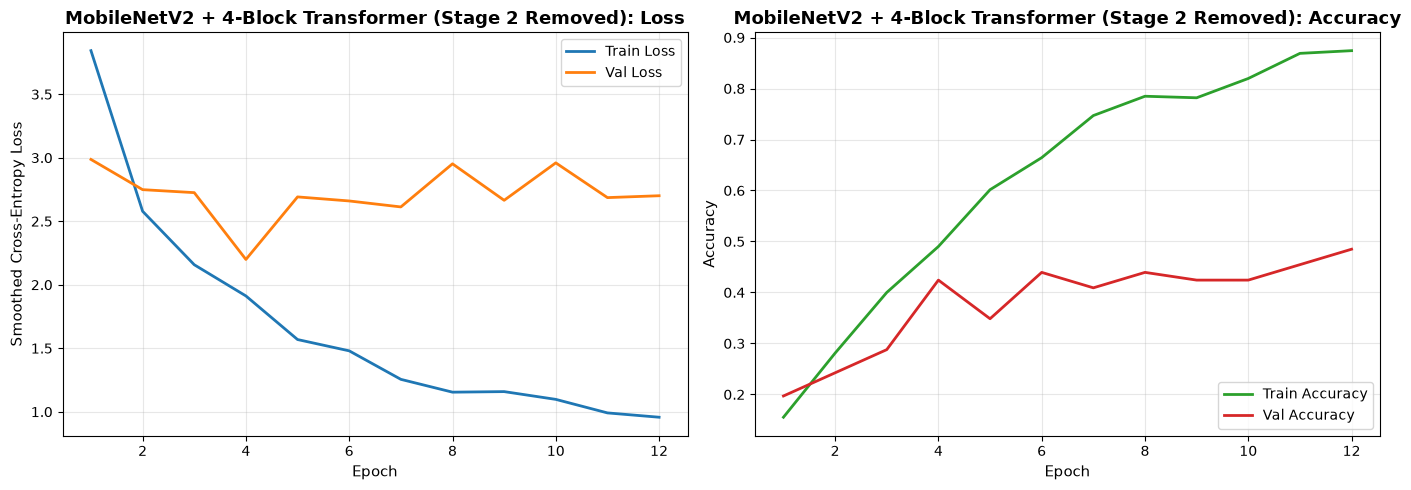

Training curves saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/training_history_curves.png


In [14]:
# Section 14: Training History Compilation & Visualization
h = history.history

training_history = {
    "epoch": list(range(1, len(h["loss"]) + 1)),
    "train_loss": h["loss"],
    "val_loss": h["val_loss"],
    "train_accuracy": h["accuracy"],
    "val_accuracy": h["val_accuracy"],
}

df_history = pd.DataFrame(training_history)
history_csv_path = RESULTS_DIR / "training_history.csv"
df_history.to_csv(history_csv_path, index=False)
print(f"Training history saved to: {history_csv_path}")

# Plotting curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
ax1.plot(df_history["epoch"], df_history["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
ax1.plot(df_history["epoch"], df_history["val_loss"], label="Val Loss", color="#ff7f0e", linewidth=2)
ax1.set_title("MobileNetV2 + 4-Block Transformer (Stage 2 Removed): Loss", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Smoothed Cross-Entropy Loss", fontsize=11)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Accuracy Curves
ax2.plot(df_history["epoch"], df_history["train_accuracy"], label="Train Accuracy", color="#2ca02c", linewidth=2)
ax2.plot(df_history["epoch"], df_history["val_accuracy"], label="Val Accuracy", color="#d62728", linewidth=2)
ax2.set_title("MobileNetV2 + 4-Block Transformer (Stage 2 Removed): Accuracy", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = RESULTS_DIR / "training_history_curves.png"
plt.savefig(curves_path, dpi=200)
plt.show()
print(f"Training curves saved to: {curves_path}")

## 15. Final Validation Evaluation
Evaluating the restored best model on the clean validation split (`X_val`, `y_val`).

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.4242 - loss: 2.1993
                     FINAL METRICS & VALIDATION EVALUATION [Mode: 80_20]
                     [MobileNetV2 Stage 2 Removed]
Validation Accuracy         : 42.42%
Validation Loss             : 2.1993
Total Parameters            : 4,697,419
Trainable Parameters        : 2,439,435 (MobileNetV2 Frozen)
Best Epoch                  : 4
Number of Training Samples  : 1,320
Number of Validation Samples: 66
Number of Train Speakers    : 24 (120 directories)
Number of Val Speakers      : 6 (6 original directories)
Validation Directories      : ['s25', 's26', 's27', 's28', 's29', 's30']
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step 


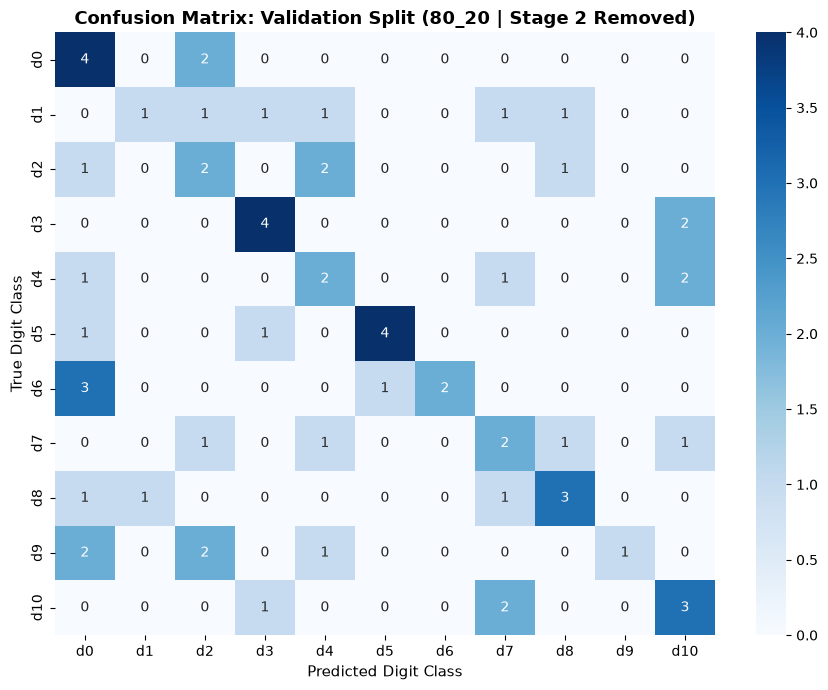

Validation confusion matrix saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/confusion_matrix_validation_80_20.png


In [15]:
# Section 15: Final Validation Evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=1)

print("=" * 80)
print(f"                     FINAL METRICS & VALIDATION EVALUATION [Mode: {DATASET_MODE}]")
print("                     [MobileNetV2 Stage 2 Removed]")
print("=" * 80)
print(f"Validation Accuracy         : {val_acc * 100:.2f}%")
print(f"Validation Loss             : {val_loss:.4f}")
print(f"Total Parameters            : {total_params:,}")
print(f"Trainable Parameters        : {trainable_params:,} (MobileNetV2 Frozen)")
print(f"Best Epoch                  : {best_epoch}")
print(f"Number of Training Samples  : {len(X_train):,}")
print(f"Number of Validation Samples: {len(X_val):,}")
print(f"Number of Train Speakers    : {len(base_train_speakers)} ({len(train_speakers)} directories)")
print(f"Number of Val Speakers      : {len(base_val_speakers)} ({len(val_speakers)} original directories)")
print(f"Validation Directories      : {val_speakers}")
print("=" * 80)

# Validation Confusion Matrix
val_probs = model.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
val_preds = np.argmax(val_probs, axis=1)

cm_val = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=DIGIT_CLASSES,
    yticklabels=DIGIT_CLASSES,
    cbar=True
)
plt.title(f"Confusion Matrix: Validation Split ({DATASET_MODE} | Stage 2 Removed)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Digit Class", fontsize=11)
plt.ylabel("True Digit Class", fontsize=11)
plt.tight_layout()

val_cm_path = RESULTS_DIR / f"confusion_matrix_validation_{DATASET_MODE}.png"
plt.savefig(val_cm_path, dpi=200)
plt.show()
print(f"Validation confusion matrix saved to: {val_cm_path}")

## 16. Final Test Evaluation (Disabled in 80/20 Mode)
In `DATASET_MODE = "80_20"`, the test split is cleanly disabled.

In [16]:
# Section 16: Final Test Evaluation
test_acc, test_prec, test_rec, test_f1 = None, None, None, None
test_preds = None

print("=" * 80)
print(f"DATASET_MODE: {DATASET_MODE}")
print("Test evaluation: DISABLED (no test split in 80/20 mode)")
print("=" * 80)

DATASET_MODE: 80_20
Test evaluation: DISABLED (no test split in 80/20 mode)


## 17. Classification Report
Generating per-class classification metrics for digits $d_0$ through $d_{10}$ on the validation partition.

In [17]:
# Section 17: Classification Report
clf_report_val = classification_report(
    y_val,
    val_preds,
    target_names=DIGIT_CLASSES,
    digits=4,
    zero_division=0
)

print("Validation Classification Report:")
print(clf_report_val)

report_path = RESULTS_DIR / f"classification_report_validation_{DATASET_MODE}.txt"
with open(report_path, "w") as f:
    f.write(clf_report_val)
print(f"Validation classification report saved to: {report_path}")

Validation Classification Report:
              precision    recall  f1-score   support

          d0     0.3077    0.6667    0.4211         6
          d1     0.5000    0.1667    0.2500         6
          d2     0.2500    0.3333    0.2857         6
          d3     0.5714    0.6667    0.6154         6
          d4     0.2857    0.3333    0.3077         6
          d5     0.8000    0.6667    0.7273         6
          d6     1.0000    0.3333    0.5000         6
          d7     0.2857    0.3333    0.3077         6
          d8     0.5000    0.5000    0.5000         6
          d9     1.0000    0.1667    0.2857         6
         d10     0.3750    0.5000    0.4286         6

    accuracy                         0.4242        66
   macro avg     0.5341    0.4242    0.4208        66
weighted avg     0.5341    0.4242    0.4208        66

Validation classification report saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_r

## 18. Save Results Artifacts
Exporting validation predictions CSV and consolidated experiment metrics JSON file to `results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/`.

In [18]:
# Section 18: Save Results Artifacts
val_manifest = df_manifest[df_manifest["split"] == "val"].copy().reset_index(drop=True)
val_manifest["predicted_digit"] = [ID_TO_CLASS[p] for p in val_preds]
val_manifest["predicted_id"] = val_preds
val_manifest["correct"] = (val_manifest["digit_id"] == val_manifest["predicted_id"])

val_predictions_csv = RESULTS_DIR / f"val_predictions_{DATASET_MODE}.csv"
val_manifest[["speaker", "base_speaker", "digit", "digit_id", "predicted_digit", "predicted_id", "correct"]].to_csv(
    val_predictions_csv, index=False
)
print(f"Validation predictions saved to: {val_predictions_csv}")

final_metrics = {
    "experiment": "mobilenetv2_transformer_4block_stage2_removed",
    "model_name": "MobileNetV2_Transformer_4Block",
    "temporal_head": "Transformer_4x_4heads_256dim",
    "stage2_status": "DISABLED",
    "dataset_mode": DATASET_MODE,
    "dataset_dir": str(DATA_DIR),
    "seed": SEED,
    "input_resolution": [FRAME_WIDTH, FRAME_HEIGHT],
    "num_frames": NUM_FRAMES,
    "num_training_samples": len(X_train),
    "num_validation_samples": len(X_val),
    "num_train_speakers": len(base_train_speakers),
    "num_train_directories": len(train_speakers),
    "num_val_speakers": len(base_val_speakers),
    "num_val_directories": len(val_speakers),
    "val_directories": val_speakers,
    "training": {
        "best_epoch": best_epoch,
        "best_val_loss": float(best_val_loss),
        "best_val_accuracy": float(best_val_acc),
        "learning_rate": STAGE1_LR,
        "max_epochs": STAGE1_MAX_EPOCHS,
        "patience": STAGE1_PATIENCE,
        "label_smoothing": LABEL_SMOOTHING,
    },
    "final_validation": {
        "loss": float(val_loss),
        "accuracy": float(val_acc),
    },
    "final_test": "DISABLED",
    "parameters": {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "mobilenetv2_frozen": True,
    }
}

metrics_json_path = RESULTS_DIR / f"metrics_{DATASET_MODE}.json"
with open(metrics_json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"Final metrics JSON saved to: {metrics_json_path}")

Validation predictions saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/val_predictions_80_20.csv
Final metrics JSON saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mobilenetv2_transformer_4block_stage2_removed_96x96_80_20/metrics_80_20.json


## 19. Final Experiment Summary
Architectural and training comparison between the Two-Stage baseline and this Stage-2-Removed controlled experiment:

| Parameter / Protocol | Two-Stage Baseline (11_mobilenetv2_transformer_4block) | Controlled Experiment (This Notebook) |
| :--- | :--- | :--- |
| **Visual Frontend** | MobileNetV2 (ImageNet weights) | MobileNetV2 (ImageNet weights, 100% frozen) |
| **Resolution** | 96 × 96 RGB (30 frames) | 96 × 96 RGB (30 frames) |
| **Temporal Head** | 4× Transformer Encoder Blocks | 4× Transformer Encoder Blocks |
| **Attention Mechanism** | Multi-Head Self-Attention (4 heads, key_dim=64) | Multi-Head Self-Attention (4 heads, key_dim=64) |
| **FFN Dimension** | 512 (GELU) | 512 (GELU) |
| **Sequence Pooling** | GlobalAveragePooling1D | GlobalAveragePooling1D |
| **Stage 1 Setup** | Frozen CNN, Adam (lr=1e-4), max 40 ep, pat 8 | Frozen CNN, Adam (lr=1e-4), max 40 ep, pat 8 |
| **Stage 2 Setup** | Unfreeze top 20%, Adam (lr=1e-5), max 25 ep, pat 6 | **DISABLED (Completely Removed)** |
| **Loss Function** | Label Smoothing ($0.1$) | Label Smoothing ($0.1$) |
| **Train Directories** | 120 (24 base speakers × 5 folders) | 120 (24 base speakers × 5 folders) |
| **Validation Directories**| 6 (6 base speakers, original only) | 6 (6 base speakers, original only) |
| **Test Partition** | Disabled (80/20 mode) | Disabled (80/20 mode) |

In [19]:
# Section 19: Final Experiment Summary Printout
print("=" * 60)
print("FINAL EVALUATION SUMMARY:")
print("MobileNetV2 + 4-Block Transformer")
print(f"[{FRAME_WIDTH}x{FRAME_HEIGHT} | Stage 2 Removed | {DATASET_MODE}]")
print("=" * 60)
print("")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Total Parameters:    {total_params}")
print(f"Trainable Parameters:{trainable_params}")
print(f"Best Epoch:          {best_epoch}")
print(f"Train Speakers:      {len(base_train_speakers)}")
print(f"Validation Speakers: {len(base_val_speakers)}")
print(f"Train Directories:   {len(train_speakers)}")
print(f"Validation Directories: {len(val_speakers)}")
print("Stage 2:             DISABLED")
print("=" * 60)

FINAL EVALUATION SUMMARY:
MobileNetV2 + 4-Block Transformer
[96x96 | Stage 2 Removed | 80_20]

Validation Accuracy: 42.42%
Validation Loss:     2.1993
Total Parameters:    4697419
Trainable Parameters:2439435
Best Epoch:          4
Train Speakers:      24
Validation Speakers: 6
Train Directories:   120
Validation Directories: 6
Stage 2:             DISABLED
